Circos visualization
================

In this vignette, you can learn how to visualize the output of a
NicheNet analysis in a circos plot (also called a chord diagram) via the
`pycirclize` package. This vignette follows the same workflow as shown in
[Perform NicheNet analysis starting from an AnnData
object](wrapper.ipynb).

This tutorial was made upon popular request to demonstrate how those two
tutorials can be combined into one analysis workflow. Note that we as
developers of NicheNet generally recommend a visualization of the output
by combining several heatmaps (ligand activity, ligand-target links,
ligand-receptor links, ligand expression, ligand LFC,…) over using a
circos plot visualization. This is especially true for cases with many
sender cell types and ligands that are expressed by more than one sender
cell type. Because in those cases, the circos plot is much less
informative and could lead to wrong interpretation of the results.

We will again use the NICHE-seq data from Medaglia et al. (2017), which
profiles several immune cell types in the T cell area in the inguinal
lymph node before and 72 hours after lymphocytic choriomeningitis virus
(LCMV) infection. 

## Prepare NicheNet analysis

In [ ]:
from nichenetpy.gene_symbol import mouse_alias_info
from nichenetpy.wrappers import (
    run_nichenet,
    create_ligand_links_circos_plot
)
from nichenetpy.visualization import assign_ligands_to_celltype

import anndata
import os
import requests
import pickle
import pandas as pd
import numpy as np

Download the model files

In [2]:
model_path = os.path.normpath("./tutorial_files/model/mouse")
if not os.path.exists(model_path):
    os.makedirs(model_path)
filename = "nichenet_mouse.pkl"
file_path = os.path.join("./tutorial_files", filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/14887637/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

Download the AnnData object

In [3]:
data_path = os.path.normpath("./tutorial_files/AnnData")
if not os.path.exists(data_path):
    os.makedirs(data_path)
filename = "annData3531889.h5"
file_path = os.path.join(data_path, filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/14859451/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

### Read in the expression data of interacting cells

In [4]:
ann = anndata.io.read_h5ad(os.path.join(data_path, "annData3531889.h5"))
ann.var_names = ann.var["gene"]
mouse_alias_info.alias_to_symbol(ann)

## Read in NicheNet's networks

The ligand-target prior model is a matrix describing the potential that a ligand may regulate a target gene, and it is used to run the ligand activity analysis. The ligand-receptor network contains information on potential ligand-receptor bindings, and it is used to identify potential ligands. 

In [5]:
with open("./tutorial_files/nichenet_mouse.pkl", "rb") as file:
    model = pickle.loads(file.read())
predictor = model["predictor"]
lr_network = model["lr_network"]
lr_sig = model["lr_sig"]

## Perform the NicheNet analysis

In [6]:
sender_celltypes = ("CD4 T", "Treg", "Mono", "NK", "B", "DC")
res = run_nichenet(
    ann,
    predictor,
    lr_network,
    "CD8 T",
    "aggregate",
    "LCMV",
    "SS",
    sender_celltypes=sender_celltypes,
    lr_sig=lr_sig,
    get_ltl=True,
    ligands_top_n=20,
    expression_pct=0.1
)
# sender focused approach
best_upstream_ligands = res["best_upstream_ligands_focused"]
active_ligand_target_links = pd.DataFrame(
    res["active_ligand_target_links_focused"],
    columns=("ligand", "target", "weight")
)
ligand_receptor_links = pd.DataFrame(res["ligand_receptor_links_focused"]._mapping, columns=("ligand", "receptor", "weight"))

## Circos plots to visualize ligand-target and ligand-receptor interactions

This visualization groups the top predicted active ligands according to
the strongest expressing cell type. Therefore we need to determine per
cell type which ligands they express more strongly than the other cell
types.

### Assign ligands to sender cells

To assign ligands to sender cell type, we can look for which sender cell
types show a mean expression that is higher than the mean + one standard
deviation. 

In [7]:
# the best upstream ligands are not necessarily present in the AnnData object
ligand_type_indication = assign_ligands_to_celltype(ann, sorted(set(best_upstream_ligands).intersection(ann.var_names)))
ligand_type_indication

,ligand_type,ligand
0,B,Btla
1,B,H2-M3
2,DC,H2-M2
3,DC,H2-D1
4,DC,H2-K1
5,DC,Selplg
6,DC,H2-Q6
7,DC,H2-Q4
8,DC,Ccl22
9,DC,H2-T23


### Define the ligand-target links of interest
We will need the ligand-target links from the NicheNet output. To avoid making a circos plots with too many ligand-target links, we will show only links with a weight higher than a predefined cutoff: links belonging to the 40% of lowest scores were removed. Not that this cutoffs and other cutoffs used for this visualization can be changed according to the user’s needs.

In [ ]:
quantile_cutoff = 0.4
df = active_ligand_target_links.merge(ligand_type_indication, how="inner")
cutoff = np.quantile(df["weight"], quantile_cutoff)
circos_df = df[df["weight"] > cutoff]
circos_ligands = set(circos_df["ligand"])
circos_targets = set(circos_df["target"])
circos_links = df[
    [
        l in circos_ligands and t in circos_targets
        for l, t in zip(df["ligand"], df["target"])
    ]
]
circos_links

,ligand,target,weight,ligand_type
0,Ebi3,Bst2,0.050041,Mono
1,Ebi3,Cd274,0.050362,Mono
2,Ebi3,Cxcl10,0.056967,Mono
3,Ebi3,Cxcr4,0.043041,Mono
4,Ebi3,Ddit4,0.048496,Mono
...,...,...,...,...
323,Cxcl10,Igfbp4,0.008390,Mono
324,Cxcl10,Irf1,0.010200,Mono
325,Cxcl10,Irf7,0.008872,Mono
326,Cxcl10,Stat1,0.008513,Mono


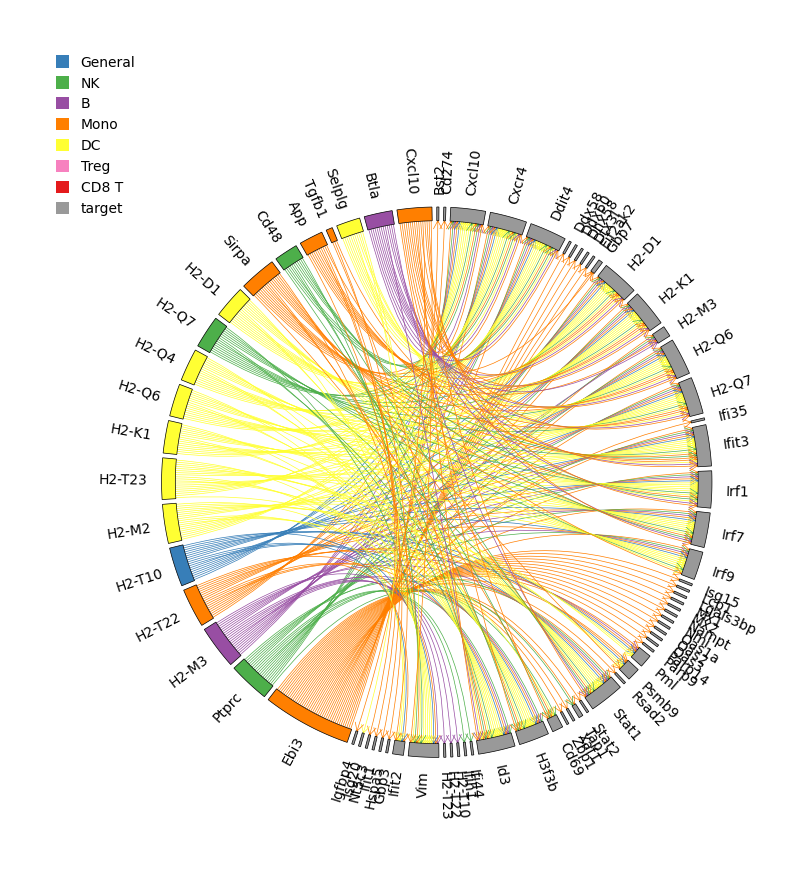

In [9]:
_ = create_ligand_links_circos_plot(
    circos_links,
    colors={
        "General": "#377EB8",
        "NK": "#4DAF4A",
        "B": "#984EA3",
        "Mono": "#FF7F00",
        "DC": "#FFFF33",
        "Treg": "#F781BF",
        "CD8 T": "#E41A1C",
        "target": "#999999"
    },
    dest_name="target"
)

### Visualize ligand-receptor interactions of the prioritized ligands in a circos plot

To create a ligand-receptor chord diagram, we can perform similar steps
as above using the weighted ligand-receptor dataframe instead. 

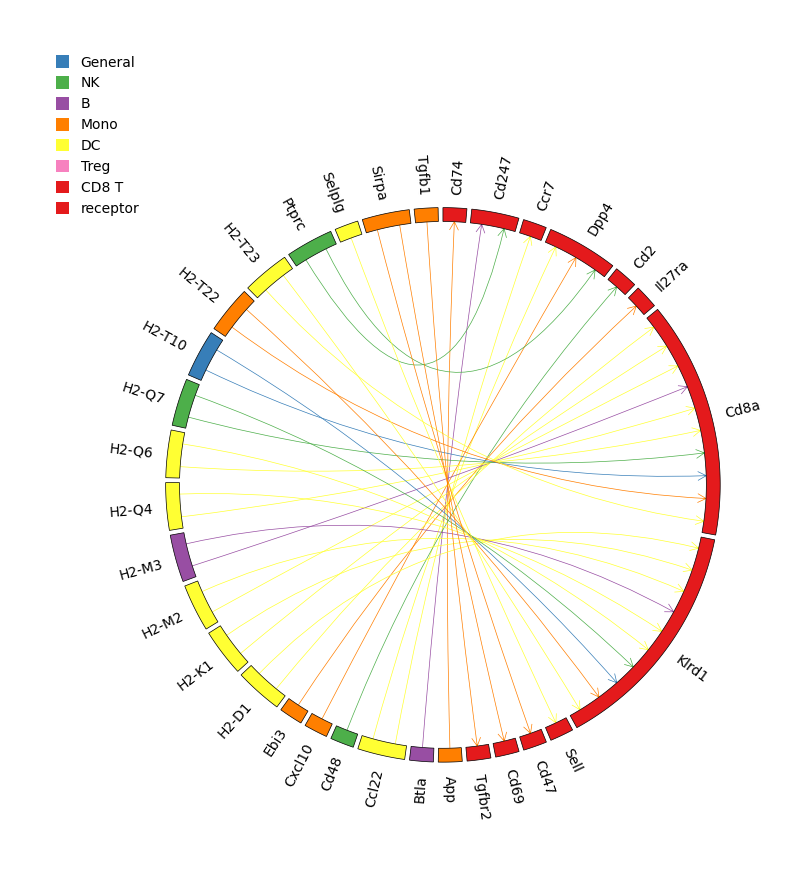

In [10]:
_ = create_ligand_links_circos_plot(
    ligand_receptor_links.merge(ligand_type_indication, how="inner"),
    colors={
        "General": "#377EB8",
        "NK": "#4DAF4A",
        "B": "#984EA3",
        "Mono": "#FF7F00",
        "DC": "#FFFF33",
        "Treg": "#F781BF",
        "CD8 T": "#E41A1C",
        "receptor": "#E41A1C"
    },
    dest_name="receptor"
)